# Niño 3.4 Multi-Horizon Forecasting with MLPs

**Author:** Zhihao Wu

In this project, I build a neural-network forecasting workflow for **Niño 3.4 multi-horizon prediction**.

I use recent Niño 3.4 index values to predict 6 future horizons, then compare several MLP-based modelling strategies:

* independent single-output MLPs
* transfer learning variants for the longest horizon
* a shared multi-output MLP
* a horizon-weighted multi-output MLP

The main question I want to explore is simple:
**does it work better to train one model per horizon, or one shared model for all horizons?**

---

## Notebook Structure

### Part 1. Environment Setup and Data Preparation

I set up the workspace, load the dataset, create train / validation / test splits, and standardize the input features. The scaler is fitted only on the training data and saved for reuse.

### Part 2. Single-Output Forecasting Models

I train 6 separate MLP baselines, one for each forecast horizon. I also test whether a short-horizon model can help initialize the longest-horizon forecast through transfer learning.

### Part 3. Multi-Output Forecasting Models

I train a shared MLP that predicts all 6 horizons in one forward pass. I also test a weighted loss function that gives more training emphasis to later horizons.

### Part 4. Model Evaluation and Comparison

I compare the models with RMSE and Pearson correlation on validation and held-out test data. I also use metric tables, learning curves, scatter plots, and horizon-level comparison charts to inspect the results.

### Part 5. Project Export

I include an optional export step for saving files from the project workspace, such as reports, figures, scalers, and trained model files.

---

## Project Focus

This project is not about claiming that one simple model is always best. I use it as a structured baseline to understand how different MLP forecasting setups behave across short and longer Niño 3.4 prediction horizons.

## Part 1. Environment Setup

I start by setting up a clean workspace for the full forecasting workflow. The goal here is simple:

- keep data, models, and preprocessing files in predictable folders
- make saved outputs easier to find later
- record the runtime environment without writing fixed machine-specific details into the narrative

I mount Google Drive so the project files are not lost when the Colab session ends. I then create separate folders for:

- raw and processed data
- trained model files
- fitted preprocessing objects

To make the experiments more controlled, I set random seeds across the main libraries I use. I also enable deterministic TensorFlow operations when the runtime supports it. This does not make every rerun identical across all machines, but it reduces avoidable randomness.

At the end, I print the active library versions, GPU status, and project paths. I treat these printed values as the runtime record for the current run, rather than hard-coding them into the Markdown.

In [1]:
# =========================================
# Part 1 — I set up the environment and project workspace
# =========================================
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# --- I define persistent folders for project files ---
from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting")
DATA_DIR     = PROJECT_ROOT / "data"
MODELS_DIR   = PROJECT_ROOT / "models"
SCALERS_DIR  = PROJECT_ROOT / "scalers"

for p in [PROJECT_ROOT, DATA_DIR, MODELS_DIR, SCALERS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# --- I set seeds to reduce unnecessary randomness during experiments ---
import os, random, numpy as np
os.environ["PYTHONHASHSEED"] = "2025"
random.seed(2025)
np.random.seed(2025)

import tensorflow as tf
try:
    tf.random.set_seed(2025)
    try:
        tf.config.experimental.enable_op_determinism(True)
    except Exception:
        pass
except Exception as e:
    print("TF seed setup warning:", e)

# --- I record the current runtime setup for traceability ---
import sys, sklearn, pandas
print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)

# --- I check whether GPU acceleration is available in this runtime ---
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", bool(gpus))
if gpus:
    try:
        details = tf.config.experimental.get_device_details(gpus[0])
        print("GPU name:", details.get("device_name", "unknown"))
    except Exception:
        print("GPU name: unknown")

# --- I print the active project paths so saved files are easy to locate ---
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("SCALERS_DIR:", SCALERS_DIR)

Mounted at /content/drive
Python: 3.12.13
TensorFlow: 2.20.0
scikit-learn: 1.6.1
pandas: 2.2.2
GPU available: True
GPU name: NVIDIA A100-SXM4-40GB
PROJECT_ROOT: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting
DATA_DIR: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/data
MODELS_DIR: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models
SCALERS_DIR: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/scalers


### Dataset Preparation

I prepare the dataset files inside the project `data/` folder so the notebook can load all inputs from one consistent workspace.

For public release, I do not include the original dataset files in this repository. To rerun the notebook, the dataset needs to be provided locally in one of two ways:

* place `Dataset.zip` in the project root, or
* place the extracted files directly under `data/`:

  * `Nino3.4_data.csv`
  * `test_years.csv`

The notebook first checks whether the extracted CSV files already exist. If they are available, it uses them directly. If not, it looks for `Dataset.zip` and extracts it into the `data/` folder. If neither option is available, the notebook stops with a clear message explaining which files need to be added.

After this step, I print:

* the target data folder
* the files currently available inside it

This gives me a quick check before moving into data loading and preprocessing, while keeping the public repository free of coursework-provided data files.

In [2]:
# =========================================
# I prepare the dataset files for local execution
# =========================================
from zipfile import ZipFile

zip_path = PROJECT_ROOT / "Dataset.zip"

data_file = DATA_DIR / "Nino3.4_data.csv"
test_years_file = DATA_DIR / "test_years.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)

if data_file.exists() and test_years_file.exists():
    print("Dataset files already found in:", DATA_DIR)

elif zip_path.exists():
    with ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)

    print("Extracted files to:", DATA_DIR)

else:
    raise FileNotFoundError(
        "Dataset files were not found.\n\n"
        "To run this notebook, provide the dataset locally using one of the following options:\n"
        "1. Place Dataset.zip in the project root, or\n"
        "2. Place Nino3.4_data.csv and test_years.csv inside the data/ folder.\n\n"
        "The dataset is not included in this public repository because it was provided as coursework material."
    )

print("Contents:")
for f in DATA_DIR.iterdir():
    print(" -", f.name)

Extracted files to: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/data
Contents:
 - Nino3.4_data.csv
 - test_years.csv


### Data Loading and Splitting

I load the prepared Niño 3.4 dataset and split it into three subsets:

- training data for model fitting
- validation data for model selection
- test data for final evaluation

I keep the test set based on the provided test-year file, so the final evaluation period stays separate from the random train-validation split. This helps me avoid mixing model tuning data with the final testing data.

For the remaining records, I create the training and validation subsets with a fixed random seed. This gives me a controlled split while still leaving a separate validation set for tuning decisions.

I then define:

- 3 recent Niño 3.4 values as input features
- 6 future Niño 3.4 values as multi-horizon prediction targets

At the end, I print the subset shapes, selected columns, and year coverage. I use these outputs as a quick check that the current split is ready before moving into preprocessing and model training.

In [3]:
# =========================================
# I load the dataset and create train, validation, and test splits
# =========================================
import pandas as pd
from sklearn.model_selection import train_test_split

# --- I read the main time-series data and the predefined test-year list ---
df = pd.read_csv(DATA_DIR / "Nino3.4_data.csv")
test_years = pd.read_csv(DATA_DIR / "test_years.csv")["year"].astype(int).tolist()

# --- I keep the predefined test years separate for final evaluation ---
df_test = df[df["year"].isin(test_years)].copy()
df_rem  = df[~df["year"].isin(test_years)].copy()

# --- I split the remaining records into training and validation data ---
train_df, val_df = train_test_split(
    df_rem, test_size=0.2, random_state=2025, shuffle=True
)

# --- I define recent Niño values as inputs and future values as prediction targets ---
features = ["nino_tminus2", "nino_tminus1", "nino_t"]
targets  = [
    "nino_tplus1", "nino_tplus2", "nino_tplus3",
    "nino_tplus4", "nino_tplus5", "nino_tplus6"
]

# --- I print split details so I can check the current run before modeling ---
print("Shapes -> train:", train_df.shape, "val:", val_df.shape, "test:", df_test.shape)
print("Feature columns:", features)
print("Target columns:", targets)
print("Year coverage (train/val/test):",
      train_df["year"].nunique(),
      val_df["year"].nunique(),
      df_test["year"].nunique())

Shapes -> train: (584, 11) val: (146, 11) test: (72, 11)
Feature columns: ['nino_tminus2', 'nino_tminus1', 'nino_t']
Target columns: ['nino_tplus1', 'nino_tplus2', 'nino_tplus3', 'nino_tplus4', 'nino_tplus5', 'nino_tplus6']
Year coverage (train/val/test): 61 53 6


### Data Preprocessing and Scaler Saving

I standardize the input features before model training so the neural networks work with a more stable numeric scale.

The scaler is fitted only on the training features. I then reuse the same fitted scaler for validation, testing, and later inference, which helps avoid data leakage from non-training records.

In this step, I:

* fit one feature scaler from the training split
* save the scaler for reuse
* define a helper function to convert feature columns into model-ready arrays
* run a quick check on the transformed training features

The printed check gives me a simple way to confirm that the scaled training features behave as expected before I move into model construction.

In [4]:
# =========================================
# I preprocess the input features and save the fitted scaler
# =========================================
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib

SCALERS_DIR.mkdir(parents=True, exist_ok=True)

# --- I fit the scaler on training features only to avoid data leakage ---
X_scaler = StandardScaler().fit(train_df[features].values.astype("float32"))
joblib.dump(X_scaler, SCALERS_DIR / "X_scaler.pkl")

# --- I convert feature DataFrames into standardized float32 arrays ---
def make_X(dframe):
    X = dframe[features].values.astype("float32")
    return X_scaler.transform(X).astype("float32")

# --- I check the transformed training features before model training ---
X_tr = make_X(train_df)
print("Train X mean (approx 0):", np.round(X_tr.mean(axis=0), 4))
print("Train X std  (approx 1):", np.round(X_tr.std(axis=0), 4))
print("Saved scaler to:", SCALERS_DIR / "X_scaler.pkl")

Train X mean (approx 0): [-0. -0.  0.]
Train X std  (approx 1): [1. 1. 1.]
Saved scaler to: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/scalers/X_scaler.pkl


### Part 1 Summary: Environment Setup and Data Preparation

In this part, I prepared the project workspace and built the basic data pipeline before model training.

I completed four setup steps:

* created a persistent Google Drive workspace
* extracted the dataset into the project `data/` folder
* split the data into training, validation, and test subsets
* fitted and saved one feature scaler using the training split only

I also defined the modelling setup for the rest of the notebook:

* 3 recent Niño 3.4 values as input features
* 6 future Niño 3.4 values as forecasting targets
* separate validation and test data for tuning and final evaluation

The main purpose of this part is to make sure the later modelling work starts from a clean and reproducible data setup, while avoiding data leakage from validation or test records.

## Part 2. Single-Output MLP Baseline

I first build a simple neural-network baseline for multi-horizon forecasting.

Instead of predicting all future steps with one model, I train one independent MLP for each forecast horizon. This gives me a clear comparison point before trying a joint multi-output model later.

For this baseline, I use:

* the standardized Niño 3.4 input features from Part 1
* 6 separate forecasting targets
* one feed-forward MLP per target horizon
* validation loss to control training progress

Each model uses a linear output layer because it predicts a continuous Niño 3.4 value. I train with mean squared error and track RMSE as an additional regression metric.

During training, I use early stopping and learning-rate reduction based on validation loss. After each horizon finishes, I save the trained model and plot the training and validation loss curves. These plots help me check whether the model is learning smoothly and whether the validation curve stays close to the training curve.


=== Training single-output MLP for horizon: tplus1 ===
Target column: nino_tplus1
Train samples: 584, Validation samples: 146
Model saved to: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus1.keras
Best epoch: 38, Best validation MSE: 0.0523


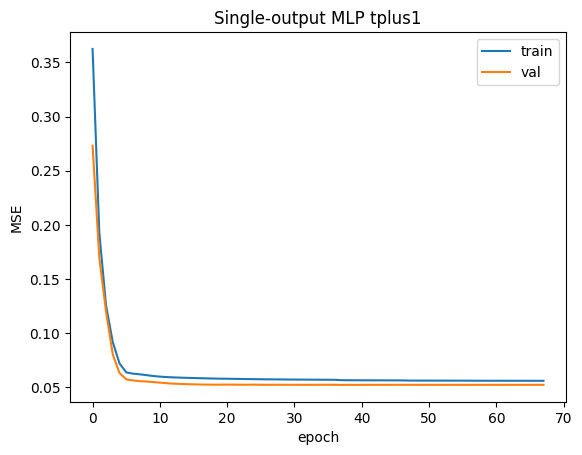


=== Training single-output MLP for horizon: tplus2 ===
Target column: nino_tplus2
Train samples: 584, Validation samples: 146
Model saved to: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus2.keras
Best epoch: 23, Best validation MSE: 0.1540


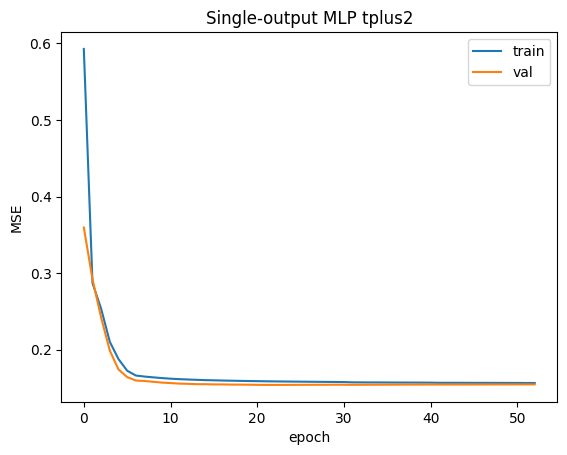


=== Training single-output MLP for horizon: tplus3 ===
Target column: nino_tplus3
Train samples: 584, Validation samples: 146
Model saved to: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus3.keras
Best epoch: 27, Best validation MSE: 0.2450


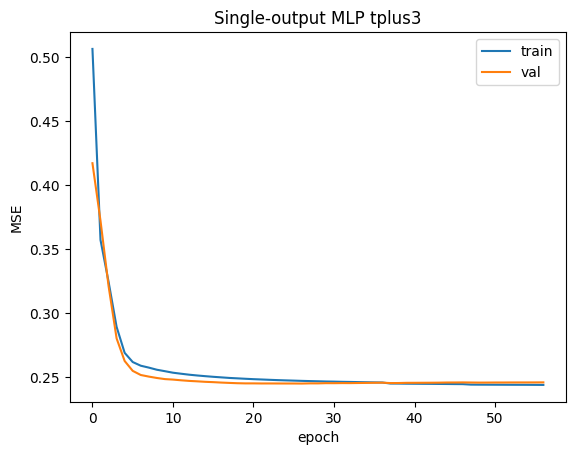


=== Training single-output MLP for horizon: tplus4 ===
Target column: nino_tplus4
Train samples: 584, Validation samples: 146
Model saved to: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus4.keras
Best epoch: 19, Best validation MSE: 0.3187


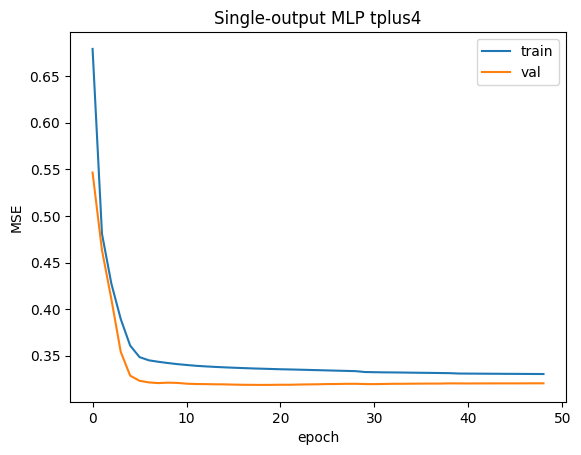


=== Training single-output MLP for horizon: tplus5 ===
Target column: nino_tplus5
Train samples: 584, Validation samples: 146
Model saved to: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus5.keras
Best epoch: 36, Best validation MSE: 0.3895


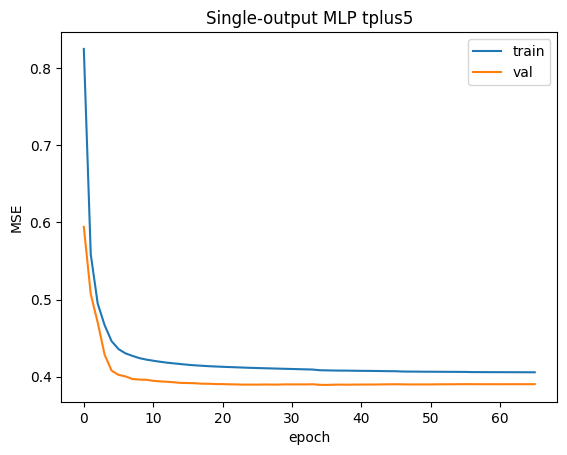


=== Training single-output MLP for horizon: tplus6 ===
Target column: nino_tplus6
Train samples: 584, Validation samples: 146
Model saved to: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus6.keras
Best epoch: 21, Best validation MSE: 0.4553


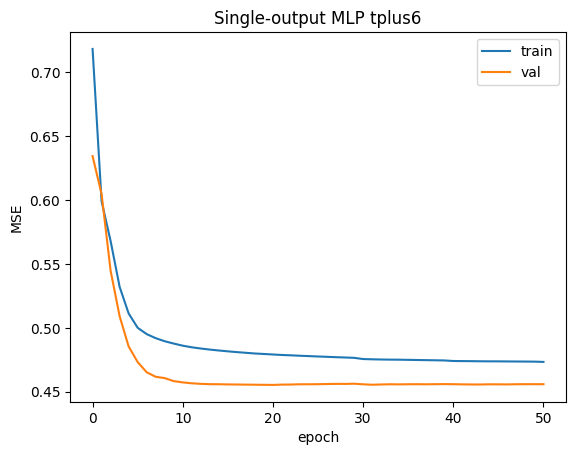


=== Summary of saved single-output MLP models ===
tplus1: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus1.keras
tplus2: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus2.keras
tplus3: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus3.keras
tplus4: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus4.keras
tplus5: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus5.keras
tplus6: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/single_output_mlp_tplus6.keras


In [5]:
# =========================================
# Part 2 — I train single-output MLP baselines for each forecast horizon
# =========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

MODELS_DIR.mkdir(parents=True, exist_ok=True)

def build_mlp(input_dim, hidden=(64, 64), lr=1e-3, l2=0.0, dropout=0.0):
    # I define a feed-forward regression model with configurable hidden layers.
    inp = keras.Input(shape=(input_dim,))
    x = inp
    for h in hidden:
        x = layers.Dense(
            h,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(l2)
        )(x)
        if dropout > 0.0:
            x = layers.Dropout(dropout)(x)

    # I use one linear output because this model predicts one horizon at a time.
    out = layers.Dense(1, name="y")(x)
    model = keras.Model(inp, out)

    # I optimize MSE and track RMSE as an additional regression metric.
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="mse",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model


def train_one_horizon(h_name, hidden=(64, 64), lr=1e-3, batch_size=64, max_epochs=500):
    # I select the target column for the current forecast horizon.
    y_col = f"nino_{h_name}"
    print(f"\n=== Training single-output MLP for horizon: {h_name} ===")
    print(f"Target column: {y_col}")

    # I reuse the fitted scaler to transform training and validation features consistently.
    X_tr = make_X(train_df)
    y_tr = train_df[y_col].values.astype("float32")
    X_va = make_X(val_df)
    y_va = val_df[y_col].values.astype("float32")
    print(f"Train samples: {len(X_tr)}, Validation samples: {len(X_va)}")

    # I build a fresh model so each horizon has its own learned parameters.
    model = build_mlp(X_tr.shape[1], hidden=hidden, lr=lr)

    # I control training with early stopping and adaptive learning-rate reduction.
    cbs = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=30,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=10,
            min_lr=1e-5
        )
    ]

    # I train quietly and keep the validation history for inspection.
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=cbs
    )

    # I save the trained model for this horizon in the project model folder.
    save_path = MODELS_DIR / f"single_output_mlp_{h_name}.keras"
    model.save(save_path)
    print(f"Model saved to: {save_path}")

    # I summarize the best validation point from the current training history.
    best_epoch = np.argmin(hist.history["val_loss"]) + 1
    best_val = np.min(hist.history["val_loss"])
    print(f"Best epoch: {best_epoch}, Best validation MSE: {best_val:.4f}")

    # I plot the train and validation MSE curves to inspect training behaviour.
    plt.figure()
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("MSE")
    plt.title(f"Single-output MLP {h_name}")
    plt.legend()
    plt.show()

    return str(save_path)


# I train one independent model for each forecast horizon.
horizons = ["tplus1", "tplus2", "tplus3", "tplus4", "tplus5", "tplus6"]
saved = []

for h in horizons:
    p = train_one_horizon(
        h,
        hidden=(64, 64),
        lr=1e-3,
        batch_size=64,
        max_epochs=500
    )
    saved.append((h, p))

# I print the saved model paths so I can check the generated files after training.
print("\n=== Summary of saved single-output MLP models ===")
for h, p in saved:
    print(f"{h}: {p}")

### Baseline Model Evaluation

I evaluate the single-output MLP baselines on both validation data and held-out test data.

For each of the 6 forecast horizons, I load the saved horizon-specific model and generate predictions with the same standardized input features. I then calculate two metrics:

* RMSE → error size
* Pearson correlation → how closely the predicted pattern follows the actual Niño 3.4 values

I collect the results into separate validation and test tables, then add an average row to give a compact view across all horizons.

The final metric report is saved as a CSV file so I can reuse it later when comparing this baseline with other modelling approaches. Any TensorFlow runtime warnings are treated as session-level messages; the main evaluation record is the metric table and saved report.

In [6]:
# =========================================
# I evaluate the saved single-output MLP models on validation and test data
# =========================================
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.stats import pearsonr

horizons = ["tplus1", "tplus2", "tplus3", "tplus4", "tplus5", "tplus6"]

def eval_single_output_mlp(df_eval, tag):
    # I transform the evaluation features with the same scaler used during training.
    X = make_X(df_eval)
    results = []

    # I load each horizon-specific model and evaluate it on the selected dataset.
    for h in horizons:
        model_path = MODELS_DIR / f"single_output_mlp_{h}.keras"
        model = tf.keras.models.load_model(model_path)

        y_true = df_eval[f"nino_{h}"].values.astype("float32")
        y_pred = model.predict(X, verbose=0).ravel().astype("float32")

        # I calculate RMSE and Pearson correlation for the current forecast horizon.
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        corr = pearsonr(y_true, y_pred)[0]

        results.append({"horizon": h, "rmse": rmse, "corr": corr})
        print(f"[{tag}] {h}: RMSE={rmse:.4f}, Corr={corr:.4f}")

    # I add an average row to summarize performance across all horizons.
    df_out = pd.DataFrame(results)
    avg = {
        "horizon": "average",
        "rmse": df_out["rmse"].mean(),
        "corr": df_out["corr"].mean()
    }
    df_out = pd.concat([df_out, pd.DataFrame([avg])], ignore_index=True)

    return df_out


print("Evaluating single-output MLP on validation set:")
val_metrics = eval_single_output_mlp(val_df, "VAL")

print("\nEvaluating single-output MLP on test set:")
test_metrics = eval_single_output_mlp(df_test, "TEST")

display(val_metrics)
display(test_metrics)

# I save validation and test metrics together for later model comparison.
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

metrics_path = REPORTS_DIR / "single_output_mlp_metrics.csv"
pd.concat([
    val_metrics.assign(set="VAL"),
    test_metrics.assign(set="TEST")
]).to_csv(metrics_path, index=False)

print("Metrics saved to:", metrics_path)

Evaluating single-output MLP on validation set:
[VAL] tplus1: RMSE=0.2287, Corr=0.9659
[VAL] tplus2: RMSE=0.3924, Corr=0.8930


[VAL] tplus3: RMSE=0.4950, Corr=0.8318
[VAL] tplus4: RMSE=0.5646, Corr=0.7659
[VAL] tplus5: RMSE=0.6241, Corr=0.6920
[VAL] tplus6: RMSE=0.6748, Corr=0.6373

Evaluating single-output MLP on test set:
[TEST] tplus1: RMSE=0.1784, Corr=0.9829
[TEST] tplus2: RMSE=0.3655, Corr=0.9288
[TEST] tplus3: RMSE=0.5274, Corr=0.8476
[TEST] tplus4: RMSE=0.6597, Corr=0.7460
[TEST] tplus5: RMSE=0.7676, Corr=0.6356
[TEST] tplus6: RMSE=0.8486, Corr=0.5368


,horizon,rmse,corr
0,tplus1,0.228727,0.965892
1,tplus2,0.392375,0.893041
2,tplus3,0.495025,0.831821
3,tplus4,0.564576,0.765894
4,tplus5,0.624069,0.691957
5,tplus6,0.674792,0.637335
6,average,0.496594,0.797657


,horizon,rmse,corr
0,tplus1,0.178442,0.982929
1,tplus2,0.365516,0.928791
2,tplus3,0.527418,0.847589
3,tplus4,0.659678,0.745997
4,tplus5,0.767596,0.635617
5,tplus6,0.848618,0.536844
6,average,0.557878,0.779628


Metrics saved to: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/reports/single_output_mlp_metrics.csv


### Transfer Learning for the Longest Forecast Horizon

I run a small transfer-learning experiment for the longest forecast horizon.

The idea is to check whether a model trained on the shortest horizon can provide a useful starting point for the hardest horizon. I load the short-horizon MLP, reuse its hidden layers, and replace the original output layer with a new regression head for the longest target.

In this experiment, I keep the reused layers trainable. This lets the full network adapt during fine-tuning instead of treating the earlier model as a fixed feature extractor.

I compare two models on the held-out test set:

* the original longest-horizon MLP baseline
* the fine-tuned transfer-learning model

For both models, I report RMSE and Pearson correlation. I also print the relative RMSE reduction against the baseline, so I can quickly see whether the transfer-based initialization helped in the current run.

Loading base model: single_output_mlp_tplus1.keras
Fine-tuning transfer model for horizon: tplus6
Saved transfer model to: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/transfer_mlp_tplus6.keras
Best epoch: 24, Best validation MSE: 0.4539


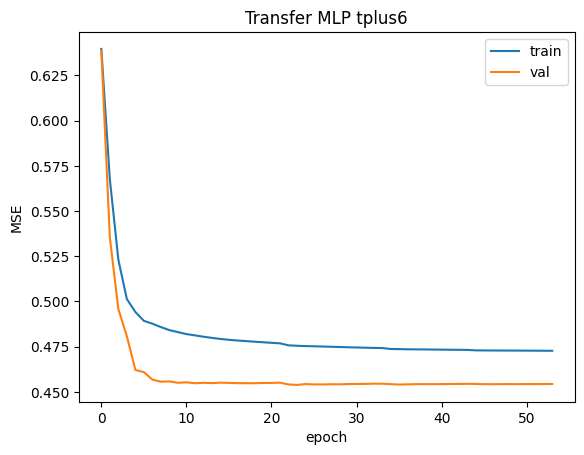

TEST t+6 baseline      RMSE=0.8486  Corr=0.5368
TEST t+6 transfer MLP  RMSE=0.8441  Corr=0.5509
Relative RMSE reduction vs baseline: 0.53%


In [7]:
# =========================================
# I fine-tune a short-horizon MLP backbone for the longest forecast horizon
# =========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

print("Loading base model: single_output_mlp_tplus1.keras")
base = tf.keras.models.load_model(MODELS_DIR / "single_output_mlp_tplus1.keras")

# I keep the reused hidden layers trainable so the backbone can adapt to the new target.
for layer in base.layers[:-1]:
    layer.trainable = True

# I replace the original output layer with a fresh regression head for the longest horizon.
x = base.layers[-2].output if len(base.layers) > 1 else base.layers[0].output
out = layers.Dense(1, name="y")(x)

tl_model = keras.Model(base.input, out)
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[keras.metrics.RootMeanSquaredError(name="rmse")]
)

# I prepare standardized inputs and longest-horizon targets for fine-tuning.
X_tr, y_tr = make_X(train_df), train_df["nino_tplus6"].values.astype("float32")
X_va, y_va = make_X(val_df),   val_df["nino_tplus6"].values.astype("float32")

# I use validation-based callbacks to control training and keep the best weights.
cbs = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )
]

print("Fine-tuning transfer model for horizon: tplus6")
hist = tl_model.fit(
    X_tr,
    y_tr,
    validation_data=(X_va, y_va),
    epochs=400,
    batch_size=64,
    verbose=0,
    callbacks=cbs
)

# I save the fine-tuned model for later evaluation or reuse.
save_path = MODELS_DIR / "transfer_mlp_tplus6.keras"
tl_model.save(save_path)
print("Saved transfer model to:", save_path)

# I record the best validation point from the current fine-tuning history.
best_epoch = np.argmin(hist.history["val_loss"]) + 1
best_val = float(np.min(hist.history["val_loss"]))
print(f"Best epoch: {best_epoch}, Best validation MSE: {best_val:.4f}")

# I plot the train and validation loss curves to inspect fine-tuning behaviour.
plt.figure()
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Transfer MLP tplus6")
plt.legend()
plt.show()

# --- I compare the fine-tuned model with the original longest-horizon baseline ---
X_te = make_X(df_test)
y_te = df_test["nino_tplus6"].values.astype("float32")

# I evaluate the fine-tuned model on the held-out test set.
yp_tl = tl_model.predict(X_te, verbose=0).ravel().astype("float32")
rmse_tl = float(np.sqrt(np.mean((y_te - yp_tl) ** 2)))
corr_tl = float(pearsonr(y_te, yp_tl)[0])

# I evaluate the original longest-horizon baseline on the same test set.
base6 = tf.keras.models.load_model(MODELS_DIR / "single_output_mlp_tplus6.keras")
yp_base = base6.predict(X_te, verbose=0).ravel().astype("float32")
rmse_base = float(np.sqrt(np.mean((y_te - yp_base) ** 2)))
corr_base = float(pearsonr(y_te, yp_base)[0])

# I print the current-run comparison and relative RMSE reduction.
print(f"TEST t+6 baseline      RMSE={rmse_base:.4f}  Corr={corr_base:.4f}")
print(f"TEST t+6 transfer MLP  RMSE={rmse_tl:.4f}  Corr={corr_tl:.4f}")
print(f"Relative RMSE reduction vs baseline: {(rmse_base - rmse_tl) / rmse_base * 100:.2f}%")

### Two-Stage Transfer Learning Schedule

I extend the transfer-learning experiment with a two-stage fine-tuning schedule for the longest forecast horizon.

The schedule has two steps:

* Stage 1 → freeze the reused hidden layers and train only the new output head
* Stage 2 → unfreeze the last hidden layer and continue fine-tuning more selectively

I use the same standardized inputs and the same longest-horizon target as the previous transfer experiment. This keeps the comparison focused on the training schedule rather than changing the data setup.

After training, I evaluate the scheduled transfer model on the held-out test set with:

* RMSE
* Pearson correlation

I then save the trained model so it can be compared with the single-output baseline and the direct transfer model later.

In [8]:
# =========================================
# I apply a two-stage transfer learning schedule for the longest forecast horizon
# =========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from scipy.stats import pearsonr

base = tf.keras.models.load_model(MODELS_DIR / "single_output_mlp_tplus1.keras")

# I first freeze the reused hidden layers so only the new output head is trained.
for layer in base.layers[:-1]:
    layer.trainable = False

# I replace the original output layer with a new regression head for the longest horizon.
x = base.layers[-2].output if len(base.layers) > 1 else base.layers[0].output
head = layers.Dense(1, name="y")(x)

model = keras.Model(base.input, head)
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="mse",
    metrics=[keras.metrics.RootMeanSquaredError(name="rmse")]
)

# I prepare the standardized inputs and target values used in both training stages.
X_tr, y_tr = make_X(train_df), train_df["nino_tplus6"].values.astype("float32")
X_va, y_va = make_X(val_df),   val_df["nino_tplus6"].values.astype("float32")

# I use validation-based callbacks to stop training and adjust the learning rate when needed.
cbs = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-5
    )
]

# I train the new output head while the reused backbone remains frozen.
hist1 = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_va, y_va),
    epochs=120,
    batch_size=64,
    verbose=0,
    callbacks=cbs
)

# I then unfreeze only the last hidden layer for a more selective fine-tuning step.
if len(base.layers) > 2:
    for layer in base.layers[:-2]:
        layer.trainable = False
    base.layers[-2].trainable = True
else:
    for layer in base.layers:
        layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="mse",
    metrics=[keras.metrics.RootMeanSquaredError(name="rmse")]
)

# I continue fine-tuning with the partially unfrozen model.
hist2 = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_va, y_va),
    epochs=120,
    batch_size=64,
    verbose=0,
    callbacks=cbs
)

# I evaluate the scheduled transfer model on the held-out test set.
X_te = make_X(df_test)
y_te = df_test["nino_tplus6"].values.astype("float32")

yp = model.predict(X_te, verbose=0).ravel().astype("float32")
rmse = float(np.sqrt(np.mean((y_te - yp) ** 2)))
corr = float(pearsonr(y_te, yp)[0])

print(f"TEST t+6 two-stage transfer MLP  RMSE={rmse:.4f}  Corr={corr:.4f}")

# I save the trained scheduled transfer model for later comparison.
model.save(MODELS_DIR / "two_stage_transfer_mlp_tplus6.keras")

TEST t+6 two-stage transfer MLP  RMSE=0.8364  Corr=0.5448


### Training History Grid

I create a compact view of the training curves for the single-output MLP baseline.

In this step, I train fresh MLP models for the 6 forecast horizons and collect their training histories. I use these runs mainly for visualization, so I treat the curves as a diagnostic snapshot from the current execution rather than fixed performance evidence.

The grid shows:

* training loss and validation loss for each horizon
* one subplot per forecast horizon
* a marker for the epoch with the lowest validation loss

This helps me compare convergence behaviour across short and long forecast horizons. I then save the figure to the reports folder so the learning-curve summary can be reused later.

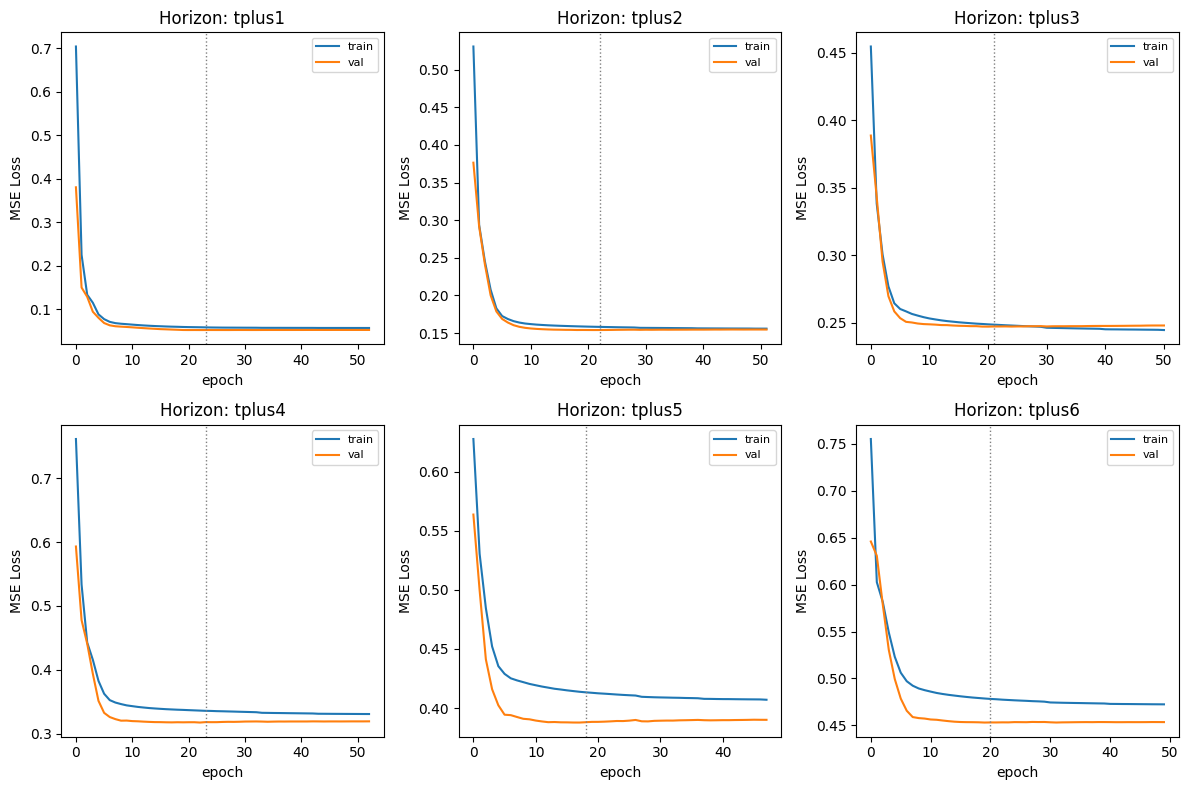

Saved: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/reports/single_output_mlp_training_histories.png


In [9]:
# =========================================
# I generate training-history plots for the single-output MLP baselines
# =========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

def build_history_mlp(input_dim, hidden=(64, 64), lr=1e-3):
    # I define a simple feed-forward regression model for one forecast horizon.
    inp = keras.Input(shape=(input_dim,))
    x = inp

    for h in hidden:
        x = layers.Dense(h, activation="relu")(x)

    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="mse"
    )
    return model


# I reuse the standardized training and validation inputs prepared earlier.
X_tr = make_X(train_df)
X_va = make_X(val_df)

horizons = ["tplus1", "tplus2", "tplus3", "tplus4", "tplus5", "tplus6"]

# I train fresh models only to collect loss histories for visualization.
histories, best_epochs = {}, {}

for h in horizons:
    y_tr = train_df[f"nino_{h}"].values.astype("float32")
    y_va = val_df[f"nino_{h}"].values.astype("float32")

    model = build_history_mlp(X_tr.shape[1], hidden=(64, 64), lr=1e-3)

    cb = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=30,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=10,
            min_lr=1e-5
        ),
    ]

    hist = model.fit(
        X_tr,
        y_tr,
        validation_data=(X_va, y_va),
        epochs=120,
        batch_size=64,
        verbose=0,
        callbacks=cb
    )

    histories[h] = hist.history
    best_epochs[h] = int(np.argmin(hist.history["val_loss"]) + 1)

# I plot all horizon-level loss curves in one grid for side-by-side inspection.
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for ax, h in zip(axes, horizons):
    loss = histories[h]["loss"]
    val_loss = histories[h]["val_loss"]

    ax.plot(loss, label="train")
    ax.plot(val_loss, label="val")
    ax.axvline(best_epochs[h], linestyle=":", color="gray", linewidth=1)

    ax.set_title(f"Horizon: {h}")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=8)

# I save the figure so the training-history summary can be reused later.
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

plt.tight_layout()
out_path = REPORTS_DIR / "single_output_mlp_training_histories.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

### Part 2 Summary: Single-Output MLP Baselines and Transfer Learning

In this part, I built and evaluated single-output MLP models for multi-horizon Niño 3.4 forecasting.

I covered four modelling and evaluation steps:

* trained 6 independent MLP baselines, one for each forecast horizon
* evaluated each horizon with RMSE and Pearson correlation
* tested transfer learning from the shortest horizon to the longest horizon
* compared direct fine-tuning with a two-stage transfer schedule

I also exported a training-history grid to inspect how the loss curves behave across all 6 horizons. The curves give me a quick visual check of convergence patterns without treating one training run as a fixed final result.

Overall, this part gives me a clear baseline setup: independent neural models for each horizon, a consistent validation/test evaluation process, and two transfer-learning checks for the longest forecast target.

## Part 3. Multi-Output MLP Baseline

I build a multi-output MLP that predicts all forecast horizons with one shared model.

This is different from the single-output setup in Part 2. Instead of training one model per horizon, I use one network to learn a shared hidden representation and output all future Niño 3.4 values in one forward pass.

In this part, I prepare:

* standardized input features from the same preprocessing pipeline
* one multi-output target matrix covering 6 forecast horizons
* a shared MLP model for joint multi-step regression

During training, I use validation-based early stopping and learning-rate reduction. After training, I save the model and plot the training and validation loss curves.

This gives me a direct baseline for comparing independent horizon-specific models with a joint multi-output forecasting approach.

Preparing multi-output data...
Train shapes: (584, 3) (584, 6) | Val shapes: (146, 3) (146, 6)
Building multi-output MLP...
Training multi-output MLP baseline...
Saved: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/multi_output_mlp_baseline.keras
Best epoch: 33, Best validation MSE: 0.2695


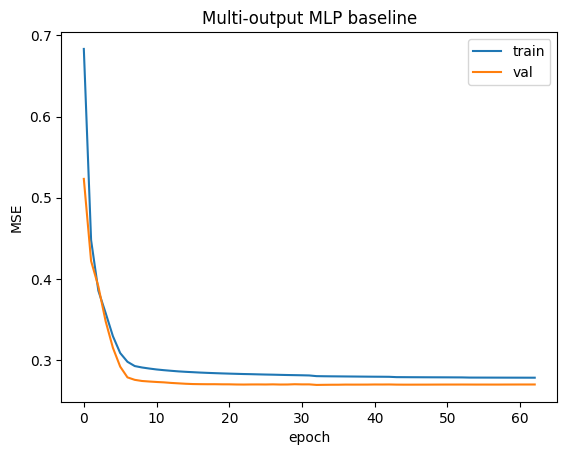

In [10]:
# =========================================
# Part 3 — I train a multi-output MLP baseline for all forecast horizons
# =========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("Preparing multi-output data...")

# I prepare standardized inputs and combine all forecast targets into one output matrix.
X_tr = make_X(train_df)
X_va = make_X(val_df)
Y_tr = train_df[[f"nino_tplus{i}" for i in range(1, 7)]].values.astype("float32")
Y_va = val_df[[f"nino_tplus{i}" for i in range(1, 7)]].values.astype("float32")

print("Train shapes:", X_tr.shape, Y_tr.shape, "| Val shapes:", X_va.shape, Y_va.shape)

def build_multi(input_dim, hidden=(128, 128), lr=1e-3, l2=0.0, dropout=0.0):
    # I define a shared feed-forward backbone for multi-horizon regression.
    inp = keras.Input(shape=(input_dim,))
    x = inp

    for h in hidden:
        x = layers.Dense(
            h,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(l2)
        )(x)
        if dropout > 0.0:
            x = layers.Dropout(dropout)(x)

    # I use one linear output vector so the model predicts all horizons together.
    out = layers.Dense(6, name="y")(x)
    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="mse",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model

print("Building multi-output MLP...")

# I build the multi-output baseline with shared hidden layers.
mo = build_multi(X_tr.shape[1], hidden=(128, 128), lr=1e-3, dropout=0.0)

# I use validation-based callbacks to control training and keep the best weights.
cbs = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )
]

print("Training multi-output MLP baseline...")

# I train the model to predict all horizons jointly.
hist = mo.fit(
    X_tr,
    Y_tr,
    validation_data=(X_va, Y_va),
    epochs=600,
    batch_size=64,
    verbose=0,
    callbacks=cbs
)

# I save the trained multi-output baseline for later evaluation.
save_path = MODELS_DIR / "multi_output_mlp_baseline.keras"
mo.save(save_path)
print("Saved:", save_path)

# I record the best validation point from the current training history.
best_epoch = int(np.argmin(hist.history["val_loss"]) + 1)
best_val = float(np.min(hist.history["val_loss"]))

print(f"Best epoch: {best_epoch}, Best validation MSE: {best_val:.4f}")

# I plot the training and validation loss curves to inspect model convergence.
plt.figure()
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Multi-output MLP baseline")
plt.legend()
plt.show()

### Multi-Output Baseline Evaluation

I evaluate the multi-output MLP baseline on both validation data and held-out test data.

The saved model predicts all 6 forecast horizons in one forward pass. For each horizon, I calculate:

* RMSE → prediction error size
* Pearson correlation → how closely the predicted pattern follows the actual Niño 3.4 values

I keep the evaluation format consistent with the single-output baseline:

* validation and test results are evaluated separately
* each horizon has its own metric row
* an average row is added for compact comparison
* the combined per-horizon report is saved as a CSV file

This gives me a clean way to compare the joint multi-output model with the independent single-output models later.

In [11]:
# =========================================
# I evaluate the multi-output MLP baseline on validation and test data
# =========================================
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.stats import pearsonr

horizons = ["tplus1", "tplus2", "tplus3", "tplus4", "tplus5", "tplus6"]

def eval_multi_output_mlp(df_eval, model_path, tag):
    # I transform the input features with the same scaler used during training.
    X = make_X(df_eval)

    # I collect all horizon targets into one matrix to match the model output.
    Y_true = df_eval[[f"nino_{h}" for h in horizons]].values.astype("float32")

    # I load the saved multi-output model and predict all horizons together.
    model = tf.keras.models.load_model(model_path)
    Y_pred = model.predict(X, verbose=0).astype("float32")

    # I calculate RMSE and Pearson correlation separately for each horizon.
    rows = []

    for i, h in enumerate(horizons):
        yt = Y_true[:, i]
        yp = Y_pred[:, i]

        rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
        corr = float(pearsonr(yt, yp)[0])

        rows.append({
            "horizon": h,
            "set": tag,
            "rmse": rmse,
            "corr": corr
        })

        print(f"[{tag}] {h}: RMSE={rmse:.4f}, Corr={corr:.4f}")

    return pd.DataFrame(rows)


# I evaluate the same saved model on validation and held-out test data.
model_path = MODELS_DIR / "multi_output_mlp_baseline.keras"

val_multi_output = eval_multi_output_mlp(val_df, model_path, "VAL")
test_multi_output = eval_multi_output_mlp(df_test, model_path, "TEST")

# I save all per-horizon metrics in one report file for later comparison.
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

out_path = REPORTS_DIR / "multi_output_mlp_metrics.csv"
pd.concat(
    [val_multi_output, test_multi_output],
    ignore_index=True
).to_csv(out_path, index=False)

print("Saved:", out_path)

def add_average(df):
    # I summarize horizon-level metrics and add an average row for compact comparison.
    summary = df.groupby("horizon", as_index=False)[["rmse", "corr"]].mean()
    summary.loc[len(summary)] = [
        "average",
        summary["rmse"].mean(),
        summary["corr"].mean()
    ]
    return summary


print("\nVAL summary:")
display(add_average(val_multi_output))

print("\nTEST summary:")
display(add_average(test_multi_output))

[VAL] tplus1: RMSE=0.2291, Corr=0.9658
[VAL] tplus2: RMSE=0.3905, Corr=0.8938
[VAL] tplus3: RMSE=0.4973, Corr=0.8298
[VAL] tplus4: RMSE=0.5651, Corr=0.7652
[VAL] tplus5: RMSE=0.6212, Corr=0.6949
[VAL] tplus6: RMSE=0.6780, Corr=0.6313
[TEST] tplus1: RMSE=0.1817, Corr=0.9826
[TEST] tplus2: RMSE=0.3634, Corr=0.9294
[TEST] tplus3: RMSE=0.5218, Corr=0.8520
[TEST] tplus4: RMSE=0.6633, Corr=0.7450
[TEST] tplus5: RMSE=0.7664, Corr=0.6346
[TEST] tplus6: RMSE=0.8511, Corr=0.5328
Saved: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/reports/multi_output_mlp_metrics.csv

VAL summary:


,horizon,rmse,corr
0,tplus1,0.229123,0.965793
1,tplus2,0.390460,0.893774
2,tplus3,0.497323,0.829772
3,tplus4,0.565066,0.765197
4,tplus5,0.621191,0.694936
5,tplus6,0.677951,0.631308
6,average,0.496852,0.796797



TEST summary:


,horizon,rmse,corr
0,tplus1,0.181733,0.982575
1,tplus2,0.363424,0.929370
2,tplus3,0.521766,0.851961
3,tplus4,0.663348,0.745014
4,tplus5,0.766449,0.634595
5,tplus6,0.851150,0.532811
6,average,0.557978,0.779387


### Horizon-Weighted Multi-Output Training

I train a second multi-output MLP with a horizon-weighted loss function.

The purpose is to test whether the shared model can put more training attention on longer forecast horizons. I keep the same input features, target matrix, and overall model structure as the standard multi-output baseline. The main change is the loss function: later horizons receive larger penalties during optimization.

After training, I evaluate the weighted model on:

* validation data
* held-out test data
* 6 forecast horizons
* 2 metrics: RMSE and Pearson correlation

I then compare the weighted model with the standard multi-output baseline on the same test set. The comparison table shows whether the weighted objective creates gains, trade-offs, or mixed effects across horizons in the current run.

Training horizon-weighted multi-output MLP...
Saved: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/models/horizon_weighted_multi_output_mlp.keras


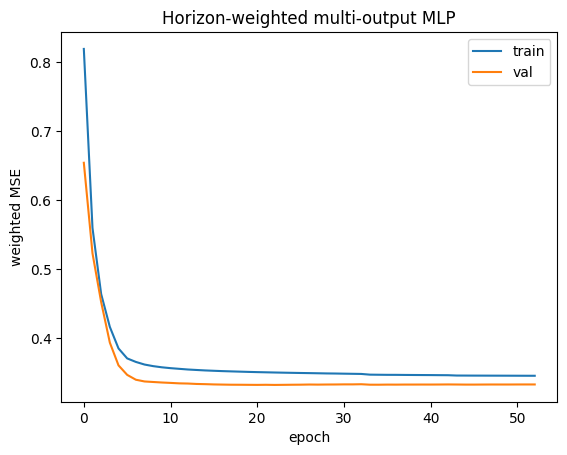

[VAL_weighted] tplus1: RMSE=0.2270, Corr=0.9665
[VAL_weighted] tplus2: RMSE=0.3911, Corr=0.8937
[VAL_weighted] tplus3: RMSE=0.4940, Corr=0.8328
[VAL_weighted] tplus4: RMSE=0.5640, Corr=0.7661
[VAL_weighted] tplus5: RMSE=0.6202, Corr=0.6976
[VAL_weighted] tplus6: RMSE=0.6746, Corr=0.6369
[TEST_weighted] tplus1: RMSE=0.1901, Corr=0.9811
[TEST_weighted] tplus2: RMSE=0.3706, Corr=0.9271
[TEST_weighted] tplus3: RMSE=0.5256, Corr=0.8501
[TEST_weighted] tplus4: RMSE=0.6590, Corr=0.7457
[TEST_weighted] tplus5: RMSE=0.7658, Corr=0.6371
[TEST_weighted] tplus6: RMSE=0.8471, Corr=0.5383
[TEST_baseline] tplus1: RMSE=0.1817, Corr=0.9826
[TEST_baseline] tplus2: RMSE=0.3634, Corr=0.9294
[TEST_baseline] tplus3: RMSE=0.5218, Corr=0.8520
[TEST_baseline] tplus4: RMSE=0.6633, Corr=0.7450
[TEST_baseline] tplus5: RMSE=0.7664, Corr=0.6346
[TEST_baseline] tplus6: RMSE=0.8511, Corr=0.5328


,horizon,rmse_baseline,rmse_weighted,rmse_reduction_%,corr_baseline,corr_weighted,corr_change_%
0,tplus1,0.181733,0.190109,-4.608567,0.982575,0.981059,-0.154251
1,tplus2,0.363424,0.370627,-1.982069,0.929370,0.927134,-0.240600
2,tplus3,0.521766,0.525584,-0.731649,0.851961,0.850119,-0.216147
3,tplus4,0.663348,0.658981,0.658237,0.745014,0.745695,0.091381
4,tplus5,0.766449,0.765796,0.085178,0.634595,0.637061,0.388730
5,tplus6,0.851150,0.847117,0.473798,0.532811,0.538340,1.037780


Saved comparison CSV: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/reports/horizon_weighted_vs_multi_output_baseline.csv


In [12]:
# =========================================
# I train and evaluate a horizon-weighted multi-output MLP
# =========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

horizons = ["tplus1", "tplus2", "tplus3", "tplus4", "tplus5", "tplus6"]

# --- I prepare standardized inputs and multi-output targets for each dataset split ---
X_tr = make_X(train_df)
X_va = make_X(val_df)
X_te = make_X(df_test)

Y_tr = train_df[[f"nino_{h}" for h in horizons]].values.astype("float32")
Y_va = val_df[[f"nino_{h}" for h in horizons]].values.astype("float32")
Y_te = df_test[[f"nino_{h}" for h in horizons]].values.astype("float32")

# --- I define a weighted MSE loss that gives later horizons larger training penalties ---
weights = tf.constant([1.0, 1.0, 1.1, 1.2, 1.3, 1.4], dtype=tf.float32)

def weighted_mse(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred) * weights)


def build_weighted_multi_output_mlp(input_dim, hidden=(128, 128), lr=1e-3, l2=0.0, dropout=0.0):
    # I use the same shared MLP structure as the standard multi-output baseline.
    inp = keras.Input(shape=(input_dim,))
    x = inp

    for h in hidden:
        x = layers.Dense(
            h,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(l2)
        )(x)
        if dropout > 0.0:
            x = layers.Dropout(dropout)(x)

    # I predict all forecast horizons together with one linear output vector.
    out = layers.Dense(6, name="y")(x)
    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss=weighted_mse,
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model


print("Training horizon-weighted multi-output MLP...")

# I train the weighted-loss model with validation-based stopping and learning-rate control.
mo_w = build_weighted_multi_output_mlp(X_tr.shape[1], hidden=(128, 128), lr=1e-3)

cbs = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )
]

hist = mo_w.fit(
    X_tr,
    Y_tr,
    validation_data=(X_va, Y_va),
    epochs=600,
    batch_size=64,
    verbose=0,
    callbacks=cbs
)

# I save the trained weighted model for later reuse and comparison.
save_path = MODELS_DIR / "horizon_weighted_multi_output_mlp.keras"
mo_w.save(save_path)
print("Saved:", save_path)

# I plot the weighted training and validation loss curves for diagnostic inspection.
plt.figure()
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("weighted MSE")
plt.title("Horizon-weighted multi-output MLP")
plt.legend()
plt.show()

# --- I define a reusable metric helper for horizon-level evaluation ---
def eval_rows(Y_true, Y_pred, tag):
    rows = []

    for i, h in enumerate(horizons):
        yt = Y_true[:, i]
        yp = Y_pred[:, i]

        rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
        corr = float(pearsonr(yt, yp)[0])

        rows.append({
            "horizon": h,
            "set": tag,
            "rmse": rmse,
            "corr": corr
        })

        print(f"[{tag}] {h}: RMSE={rmse:.4f}, Corr={corr:.4f}")

    return pd.DataFrame(rows)


# --- I evaluate the weighted model on validation and held-out test data ---
Yv_pred = mo_w.predict(X_va, verbose=0).astype("float32")
Yt_pred = mo_w.predict(X_te, verbose=0).astype("float32")

val_w = eval_rows(Y_va, Yv_pred, "VAL_weighted")
test_w = eval_rows(Y_te, Yt_pred, "TEST_weighted")

# --- I load the standard multi-output baseline and evaluate it on the same test data ---
base = tf.keras.models.load_model(MODELS_DIR / "multi_output_mlp_baseline.keras")
Yt_base = base.predict(X_te, verbose=0).astype("float32")
test_b = eval_rows(Y_te, Yt_base, "TEST_baseline")

# --- I compare weighted-loss performance against the baseline for each horizon ---
comp = test_w.merge(test_b, on="horizon", suffixes=("_weighted", "_baseline"))

comp["rmse_reduction_%"] = (
    100.0
    * (comp["rmse_baseline"] - comp["rmse_weighted"])
    / comp["rmse_baseline"]
)

comp["corr_change_%"] = (
    100.0
    * (comp["corr_weighted"] - comp["corr_baseline"])
    / np.maximum(1e-8, np.abs(comp["corr_baseline"]))
)

display(comp[
    [
        "horizon",
        "rmse_baseline",
        "rmse_weighted",
        "rmse_reduction_%",
        "corr_baseline",
        "corr_weighted",
        "corr_change_%"
    ]
])

# I save the comparison table so the weighted-loss experiment can be reviewed later.
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

out_csv = REPORTS_DIR / "horizon_weighted_vs_multi_output_baseline.csv"
comp.to_csv(out_csv, index=False)

print("Saved comparison CSV:", out_csv)

### Test-Set Prediction Scatter Plots

I visualize the multi-output MLP predictions on the held-out test set.

For each of the 6 forecast horizons, I plot observed Niño 3.4 values against predicted values. The dashed diagonal line represents perfect prediction, so points closer to this line indicate stronger agreement between the model and the actual values.

Each subplot includes the current-run RMSE and correlation in the title. I treat these numbers as part of the generated diagnostic figure, not as fixed Markdown claims.

This figure helps me check:

* short-horizon vs long-horizon prediction quality
* whether predictions follow the observed trend
* where the model starts to lose accuracy as the forecast horizon gets longer

I save the scatter-plot grid to the reports folder for later review.

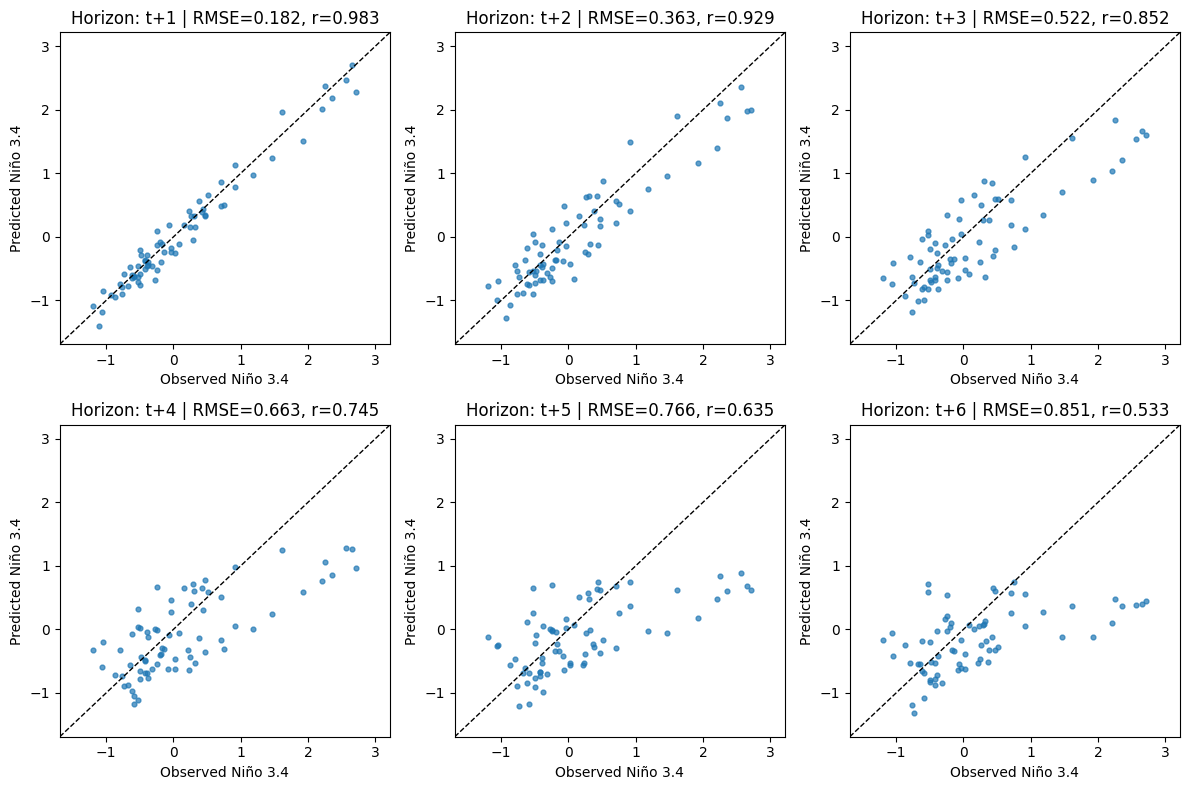

Saved: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/reports/multi_output_mlp_test_scatter.png


In [13]:
# =========================================
# I visualize test-set predictions from the multi-output MLP baseline
# =========================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

hlabels = ["t+1", "t+2", "t+3", "t+4", "t+5", "t+6"]

# I load the saved multi-output baseline model for test-set visualization.
model = tf.keras.models.load_model(MODELS_DIR / "multi_output_mlp_baseline.keras")

# I prepare standardized test inputs and the corresponding multi-horizon targets.
X_te = make_X(df_test)
Y_true = df_test[[f"nino_tplus{i}" for i in range(1, 7)]].values.astype("float32")
Y_pred = model.predict(X_te, verbose=0).astype("float32")

# I create one scatter plot per forecast horizon for side-by-side comparison.
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

xymin = float(np.min(Y_true) - 0.5)
xymax = float(np.max(Y_true) + 0.5)

for i, ax in enumerate(axes):
    yt = Y_true[:, i]
    yp = Y_pred[:, i]

    # I calculate horizon-level metrics for the current plot title.
    rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
    corr = float(np.corrcoef(yt, yp)[0, 1])

    # I compare observed and predicted values against the perfect-prediction line.
    ax.scatter(yt, yp, s=12, alpha=0.7)
    ax.plot([xymin, xymax], [xymin, xymax], "k--", lw=1)

    ax.set_xlim(xymin, xymax)
    ax.set_ylim(xymin, xymax)

    ax.set_title(f"Horizon: {hlabels[i]} | RMSE={rmse:.3f}, r={corr:.3f}")
    ax.set_xlabel("Observed Niño 3.4")
    ax.set_ylabel("Predicted Niño 3.4")

# I save the diagnostic scatter-plot grid for later review.
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

plt.tight_layout()
out_path = REPORTS_DIR / "multi_output_mlp_test_scatter.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

### Weighted Model Test-Set Scatter Plots

I visualize the horizon-weighted multi-output MLP on the held-out test set.

For each of the 6 forecast horizons, I compare the true Niño 3.4 values with the model predictions in a separate scatter plot. I also add an ideal one-to-one reference line, so points closer to this line indicate stronger agreement between the predicted and observed values.

The subplot titles show the RMSE and correlation from the current run. I treat these values as part of the generated figure rather than fixed Markdown claims.

This figure helps me inspect:

- how prediction quality changes across the 6 horizons
- whether the weighted model still follows the overall target pattern
- whether longer-horizon predictions become more aligned after using the weighted loss

I save the scatter-plot grid to the reports folder so I can compare it with the standard multi-output baseline later.

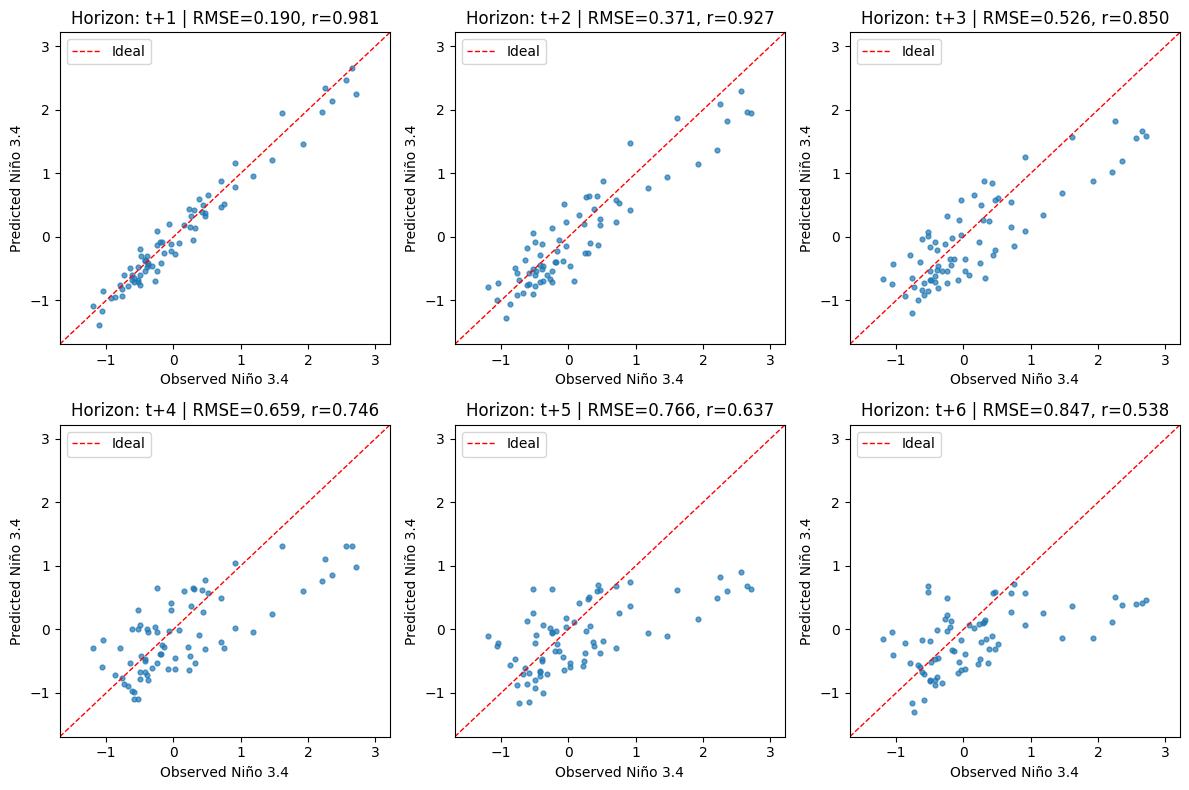

Saved: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/reports/horizon_weighted_multi_output_test_scatter.png


In [14]:
# =========================================
# I visualize test-set predictions from the horizon-weighted multi-output model
# =========================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

hlabels = ["t+1", "t+2", "t+3", "t+4", "t+5", "t+6"]

# I load the weighted model for prediction only, so the custom loss is not needed here.
model = tf.keras.models.load_model(
    MODELS_DIR / "horizon_weighted_multi_output_mlp.keras",
    compile=False  # prediction only; no custom_objects needed
)

# I prepare standardized test inputs and the corresponding multi-horizon target values.
X_te = make_X(df_test)
Y_true = df_test[[f"nino_tplus{i}" for i in range(1, 7)]].values.astype("float32")
Y_pred = model.predict(X_te, verbose=0).astype("float32")

# I create one scatter plot per forecast horizon for visual comparison.
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

xymin = float(np.min(Y_true) - 0.5)
xymax = float(np.max(Y_true) + 0.5)

for i, ax in enumerate(axes):
    yt = Y_true[:, i]
    yp = Y_pred[:, i]

    # I calculate horizon-level metrics for the current plot title.
    rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
    corr = float(np.corrcoef(yt, yp)[0, 1])

    # I compare predictions against the ideal one-to-one reference line.
    ax.scatter(yt, yp, s=12, alpha=0.7)
    ax.plot([xymin, xymax], [xymin, xymax], "r--", lw=1, label="Ideal")

    ax.set_xlim(xymin, xymax)
    ax.set_ylim(xymin, xymax)

    ax.set_title(f"Horizon: {hlabels[i]} | RMSE={rmse:.3f}, r={corr:.3f}")
    ax.set_xlabel("Observed Niño 3.4")
    ax.set_ylabel("Predicted Niño 3.4")
    ax.legend(loc="upper left", frameon=True)

# I save the weighted-model scatter grid for later comparison.
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

out_path = REPORTS_DIR / "horizon_weighted_multi_output_test_scatter.png"
plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

### Part 3 Summary: Multi-Output Forecasting and Horizon Weighting

In this part, I moved from independent horizon-specific models to shared multi-output forecasting.

I built and evaluated two joint models:

* a standard multi-output MLP that predicts all 6 horizons at once
* a horizon-weighted multi-output MLP that gives larger training penalties to later horizons

For both models, I used the same standardized inputs and evaluated results with:

* validation and held-out test data
* RMSE and Pearson correlation
* per-horizon tables and average rows
* scatter plots for test-set prediction diagnostics

I also compared the weighted model against the standard multi-output baseline to check whether the weighted objective improves longer-horizon behaviour or creates trade-offs across horizons.

Overall, this part gives me a direct comparison between standard joint forecasting and weighted joint forecasting, while keeping the evaluation format consistent with the single-output models from Part 2.

## Part 4. Overall Model Comparison

I combine the saved evaluation reports and compare the main forecasting strategies under the same held-out test-set format.

The comparison includes:

* single-output MLP models
* standard multi-output MLP
* horizon-weighted multi-output MLP

I load the saved metric reports, keep the test-set results, and merge them by forecast horizon. This gives me one table with RMSE and Pearson correlation for each model family.

I then calculate relative changes against the standard multi-output baseline:

* RMSE reduction → positive values mean lower error than the baseline
* correlation change → positive values mean stronger linear agreement than the baseline

Finally, I summarize the average performance across all 6 horizons and plot the horizon-level trends for RMSE and correlation. This helps me see whether the models behave differently as the forecast step becomes longer.

,horizon,rmse_single,corr_single,rmse_multi,corr_multi,rmse_weighted,corr_weighted,rmse_reduction_single_vs_multi_%,rmse_reduction_weighted_vs_multi_%,corr_change_single_vs_multi_%,corr_change_weighted_vs_multi_%
0,tplus1,0.178442,0.982929,0.181733,0.982575,0.190109,0.981059,1.811330,-4.608567,0.036005,-0.154251
1,tplus2,0.365516,0.928791,0.363424,0.929370,0.370627,0.927134,-0.575638,-1.982069,-0.062249,-0.240600
2,tplus3,0.527418,0.847589,0.521766,0.851961,0.525584,0.850119,-1.083223,-0.731649,-0.513104,-0.216147
3,tplus4,0.659678,0.745997,0.663348,0.745014,0.658981,0.745695,0.553251,0.658237,0.131863,0.091381
4,tplus5,0.767596,0.635617,0.766449,0.634595,0.765796,0.637061,-0.149686,0.085178,0.161127,0.388730
5,tplus6,0.848618,0.536844,0.851150,0.532811,0.847117,0.538340,0.297466,0.473798,0.757033,1.037780


Saved comparison table: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting/reports/model_comparison_test_metrics.csv


,Model,Avg RMSE,Avg Corr,Avg RMSE reduction vs multi-output (%),Avg Corr change vs multi-output (%)
0,Single-output MLP,0.557878,0.779628,0.017996,0.030842
1,Multi-output MLP,0.557978,0.779387,0.000000,0.000000
2,Horizon-weighted multi-output MLP,0.559702,0.779901,-0.308977,0.065947


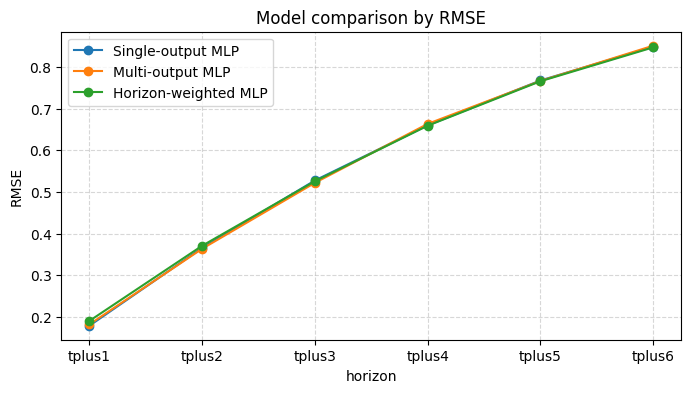

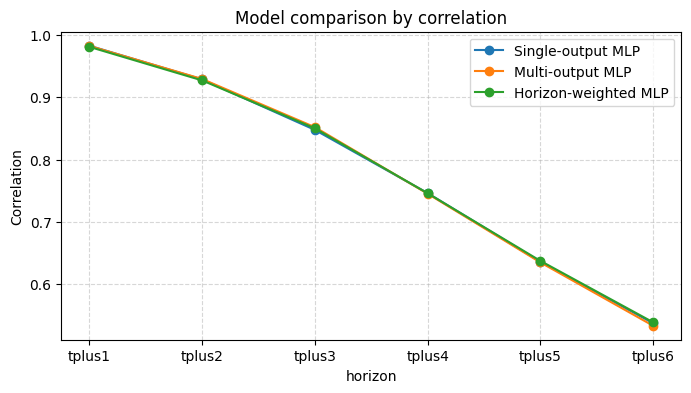

In [15]:
# =========================================
# Part 4 — I compare model evaluation reports across forecasting strategies
# =========================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- I load the saved metric reports from previous evaluations ---
single_output = pd.read_csv(REPORTS_DIR / "single_output_mlp_metrics.csv")
multi_output = pd.read_csv(REPORTS_DIR / "multi_output_mlp_metrics.csv")
weighted_compare = pd.read_csv(REPORTS_DIR / "horizon_weighted_vs_multi_output_baseline.csv")

# --- I keep only test-set horizon rows and rename columns for model-level comparison ---
single_test = (
    single_output[
        (single_output["set"] == "TEST") &
        (single_output["horizon"] != "average")
    ][["horizon", "rmse", "corr"]]
    .rename(columns={"rmse": "rmse_single", "corr": "corr_single"})
)

multi_test = (
    multi_output[
        (multi_output["set"] == "TEST") &
        (multi_output["horizon"] != "average")
    ][["horizon", "rmse", "corr"]]
    .rename(columns={"rmse": "rmse_multi", "corr": "corr_multi"})
)

weighted_test = (
    weighted_compare[["horizon", "rmse_weighted", "corr_weighted"]]
    .rename(columns={
        "rmse_weighted": "rmse_weighted",
        "corr_weighted": "corr_weighted"
    })
)

# --- I merge all test-set metrics by forecast horizon ---
df = (
    single_test
    .merge(multi_test, on="horizon")
    .merge(weighted_test, on="horizon")
    .copy()
)

# --- I calculate relative changes against the standard multi-output baseline ---
df["rmse_reduction_single_vs_multi_%"] = (
    100.0 * (df["rmse_multi"] - df["rmse_single"]) / df["rmse_multi"]
)

df["rmse_reduction_weighted_vs_multi_%"] = (
    100.0 * (df["rmse_multi"] - df["rmse_weighted"]) / df["rmse_multi"]
)

df["corr_change_single_vs_multi_%"] = (
    100.0 * (df["corr_single"] - df["corr_multi"]) / np.maximum(1e-8, np.abs(df["corr_multi"]))
)

df["corr_change_weighted_vs_multi_%"] = (
    100.0 * (df["corr_weighted"] - df["corr_multi"]) / np.maximum(1e-8, np.abs(df["corr_multi"]))
)

# --- I define a readable column order for the comparison table ---
cols = [
    "horizon",
    "rmse_single", "corr_single",
    "rmse_multi", "corr_multi",
    "rmse_weighted", "corr_weighted",
    "rmse_reduction_single_vs_multi_%",
    "rmse_reduction_weighted_vs_multi_%",
    "corr_change_single_vs_multi_%",
    "corr_change_weighted_vs_multi_%"
]

display(df[cols])

# --- I save the merged comparison table for later review ---
comparison_path = REPORTS_DIR / "model_comparison_test_metrics.csv"
df[cols].to_csv(comparison_path, index=False)
print("Saved comparison table:", comparison_path)

# --- I summarize average performance across all forecast horizons ---
summary = pd.DataFrame({
    "Model": [
        "Single-output MLP",
        "Multi-output MLP",
        "Horizon-weighted multi-output MLP"
    ],
    "Avg RMSE": [
        df["rmse_single"].mean(),
        df["rmse_multi"].mean(),
        df["rmse_weighted"].mean()
    ],
    "Avg Corr": [
        df["corr_single"].mean(),
        df["corr_multi"].mean(),
        df["corr_weighted"].mean()
    ],
    "Avg RMSE reduction vs multi-output (%)": [
        100.0 * (df["rmse_multi"].mean() - df["rmse_single"].mean()) / df["rmse_multi"].mean(),
        0.0,
        100.0 * (df["rmse_multi"].mean() - df["rmse_weighted"].mean()) / df["rmse_multi"].mean()
    ],
    "Avg Corr change vs multi-output (%)": [
        100.0 * (df["corr_single"].mean() - df["corr_multi"].mean()) / np.maximum(1e-8, abs(df["corr_multi"].mean())),
        0.0,
        100.0 * (df["corr_weighted"].mean() - df["corr_multi"].mean()) / np.maximum(1e-8, abs(df["corr_multi"].mean()))
    ]
})

display(summary)

# --- I plot RMSE trends across forecast horizons for all compared models ---
plt.figure(figsize=(8, 4))
plt.plot(df["horizon"], df["rmse_single"], marker="o", label="Single-output MLP")
plt.plot(df["horizon"], df["rmse_multi"], marker="o", label="Multi-output MLP")
plt.plot(df["horizon"], df["rmse_weighted"], marker="o", label="Horizon-weighted MLP")
plt.xlabel("horizon")
plt.ylabel("RMSE")
plt.title("Model comparison by RMSE")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- I plot correlation trends across forecast horizons for all compared models ---
plt.figure(figsize=(8, 4))
plt.plot(df["horizon"], df["corr_single"], marker="o", label="Single-output MLP")
plt.plot(df["horizon"], df["corr_multi"], marker="o", label="Multi-output MLP")
plt.plot(df["horizon"], df["corr_weighted"], marker="o", label="Horizon-weighted MLP")
plt.xlabel("horizon")
plt.ylabel("Correlation")
plt.title("Model comparison by correlation")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Part 4 Summary: Overall Model Comparison

In this part, I compared the main forecasting strategies under the same held-out test-set evaluation setup.

I combined the saved reports for three model families:

* single-output MLP
* standard multi-output MLP
* horizon-weighted multi-output MLP

For each model, I compared results across 6 forecast horizons using:

* RMSE
* Pearson correlation
* horizon-level tables
* average performance summaries
* RMSE and correlation trend plots

I also changed the relative RMSE comparison into a reduction-based interpretation, where positive values clearly mean lower error than the standard multi-output baseline.

Overall, this part gives me a compact view of how the different forecasting strategies behave as the prediction horizon becomes longer.

## Part 5. Project Export

I create a ZIP archive of the full project folder so the notebook, generated reports, figures, saved preprocessing objects, and trained model files can be downloaded together.

This step is useful when I want to keep a portable copy of the full project output from the current Colab session. I save the ZIP file under `/content`, which makes it easy to download without placing the archive back inside the project folder.

Before creating the new archive, I remove any older ZIP file with the same name. This helps prevent downloading a stale version when I rerun the notebook. After compression, I print the archive path and source folder for a quick final check, then download the ZIP file to my local machine.

In [16]:
# =========================================
# Part 5 — I export the project folder as a downloadable ZIP archive
# =========================================
import shutil
from google.colab import files
import os

# I define the ZIP output path under /content so it is easy to create and download.
zip_base = "/content/nino34_multi_horizon_forecasting"
zip_path = f"{zip_base}.zip"

# I remove any older ZIP with the same name to avoid downloading a stale copy.
if os.path.exists(zip_path):
    os.remove(zip_path)

# I compress the project folder, including files saved under PROJECT_ROOT.
shutil.make_archive(zip_base, "zip", PROJECT_ROOT)

# I print the archive path and source folder for a quick final check.
print("ZIP file created successfully.")
print("ZIP path:", zip_path)
print("Source folder:", PROJECT_ROOT)

# I trigger the ZIP download from the Colab session.
files.download(zip_path)

ZIP file created successfully.
ZIP path: /content/nino34_multi_horizon_forecasting.zip
Source folder: /content/drive/MyDrive/Nino34_Multi_Horizon_Forecasting


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Part 5 Summary: Project Export

In this part, I created a downloadable ZIP archive from the project workspace.

The export step collects files saved under the project folder, including:

* reports
* figures
* saved scalers
* trained model files
* any extra files I manually place in the workspace

I save the archive outside the project folder and remove older ZIP files with the same name before creating a new one. This helps me avoid downloading an outdated copy after rerunning the notebook.

This step is mainly for keeping a portable local copy of the current Colab project output. For GitHub, I would still keep the repository lighter and avoid uploading large generated files unless they are necessary.

# Overall Reflection and Future Work

In this project, I built a neural-network workflow for **Niño 3.4 multi-horizon forecasting**.

The main goal was to compare different MLP-based strategies for predicting several future Niño 3.4 values from recent index observations.

The workflow covers:

* environment setup and data preparation
* train / validation / test splitting
* feature standardization without data leakage
* single-output MLP baselines
* transfer learning checks for the longest horizon
* multi-output MLP forecasting
* horizon-weighted loss training
* metric tables, plots, and model comparison
* optional project export

---

## What I Built

### Data and Preprocessing

I loaded the Niño 3.4 dataset, kept the predefined test years separate, and created training and validation splits from the remaining data.

I used a scaler fitted only on the training features, then reused the same scaler for validation, testing, and later inference. This keeps the preprocessing consistent and avoids leaking information from non-training data.

Key setup choices:

* 3 recent Niño 3.4 values as input features
* 6 future Niño 3.4 values as prediction targets
* 3 data subsets: train, validation, and held-out test
* 1 saved feature scaler reused across all models

---

### Single-Output Forecasting

I first trained independent MLP models for each forecast horizon.

This gave me a simple baseline where each horizon has its own model parameters. It also made it easier to inspect how prediction difficulty changes from shorter to longer horizons.

In this stage, I built:

* 6 single-output MLP baselines
* horizon-level RMSE and Pearson correlation tables
* training-history plots for diagnostic checks
* transfer learning variants for the longest horizon

The transfer learning experiments reused the shortest-horizon model as a starting point for the longest-horizon target. This helped me test whether short-term forecasting representations could be useful for longer-term prediction.

---

### Multi-Output Forecasting

I then moved from independent models to shared multi-output forecasting.

Instead of training one model per horizon, the multi-output MLP predicts all 6 horizons in one forward pass. This lets the model learn a shared hidden representation across future steps.

I compared two joint models:

* standard multi-output MLP
* horizon-weighted multi-output MLP

The weighted version gives larger training penalties to later horizons. I used it to check whether the model could shift more attention toward longer-range forecasts.

---

## Evaluation

I evaluated the models with:

* RMSE for prediction error
* Pearson correlation for pattern agreement
* validation and held-out test results
* per-horizon tables and average summaries
* predicted-versus-observed scatter plots
* RMSE and correlation trend plots across horizons

The final comparison shows that the model families behave similarly overall, with differences appearing more clearly at specific horizons rather than one method dominating every metric.

This is useful because it gives me a practical baseline: I can see where simple MLP models are already competitive, and where longer-horizon forecasting still becomes harder.

---

## Limitations

### Model Scope

The models are based on fully connected MLPs.
This keeps the comparison clean, but MLPs do not explicitly model temporal order in the same way as recurrent, convolutional, or attention-based sequence models.

### Input Features

The workflow uses a compact set of recent Niño 3.4 values.
This keeps the experiment focused, but it does not include broader ocean-atmosphere signals that may be important for ENSO forecasting.

### Tuning

The experiments use fixed model settings within each section.
A stronger comparison could test more combinations of:

* hidden-layer sizes
* learning rates
* regularization
* dropout
* loss weights
* fine-tuning schedules

### Interpretability

The models provide useful forecasting baselines, but they do not explain the physical drivers behind the predictions.
Additional interpretability analysis would be needed to understand how each input affects each forecast horizon.

---

## Future Work

The next improvements I would consider are:

* testing sequence models such as LSTM, GRU, TCN, or Transformer-based forecasters
* adding richer climate indicators beyond recent Niño 3.4 values
* using ensemble or probabilistic methods for uncertainty estimation
* running a more systematic hyperparameter search
* applying feature attribution methods such as SHAP, permutation importance, or integrated gradients

---

## Final Takeaway

This project gives me a compact baseline for Niño 3.4 multi-horizon forecasting.

I compared:

* independent single-output MLPs
* transfer learning variants
* a standard multi-output MLP
* a horizon-weighted multi-output MLP

Across the project, I kept the evaluation consistent across 6 horizons and 2 main metrics. The result is a clear starting point for future climate time-series experiments, especially if I want to extend the work with richer features or stronger sequence-based models.